<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Sebastián Ceballes


# Evaluación Estadística de Estimadores de Frecuencia y Amplitud

## 1. Introducción y Objetivo del Trabajo

En el presente trabajo analizaremos el desempeño de distintos estimadores de amplitud ($\hat{a}_1$) y frecuencia ($\hat{\Omega}_1$) aplicados a una señal senoidal contaminada con ruido blanco gaussiano aditivo (AWGN). Basándonos en los conceptos teóricos del capítulo 14 de Holton (*DSP Principles and Applications*), el objetivo principal es evaluar cómo la elección de diferentes ventanas temporales (Rectangular, Flattop, Blackman-Harris y Hann) afecta la precisión y exactitud de la estimación.

Dado que la frecuencia exacta de la señal y el ruido aditivo introducen variabilidad, implementaremos simulaciones de Monte Carlo con 200 realizaciones para dos escenarios de relación señal a ruido (SNR: 3 dB y 10 dB). A partir de la Transformada Rápida de Fourier (FFT), extraeremos el módulo máximo y su ubicación frecuencial para calcular el sesgo y la varianza de cada estimador. Finalmente, contrastaremos los resultados mediante histogramas y tablas resumen para determinar empíricamente qué ventana ofrece mayor robustez frente al ruido y a la incertidumbre frecuencial (efecto de *spectral leakage*).

## 2. Configuración Inicial y Parámetros del Sistema

En esta primera etapa, importamos las librerías necesarias y definimos los parámetros fundamentales de la simulación. Trabajaremos con secuencias de $N = 1000$ muestras. La señal base es una senoidal cuya frecuencia central es $\Omega_0 = \frac{\pi}{2}$ y su amplitud nominal es $a_0 = \sqrt{2}$, lo que garantiza que la potencia media de la señal original sea exactamente $1 \text{ W}$.

Además, fijamos una semilla para el generador de números aleatorios (`np.random.seed`), asegurando que todos los ensayos posteriores sean reproducibles.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as windows

# Fijamos la semilla para reproducibilidad 
np.random.seed(42)

# %% Definiciones
fs = 1000  # Hz
N = 1000   # Muestras
R = 200    # Realizaciones
omega_cero = np.pi/2
a0 = np.sqrt(2)

# Identifico la fila donde corresponde el estimador
k_omega_cero = int((omega_cero / (2*np.pi)) * N) # da 250

## 3. Generación de la Señal Aleatoria y Ventanas Temporales

La señal a analizar se define matemáticamente como:
$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$

Donde la frecuencia real de la señal $\Omega_1$ presenta una incertidumbre modelada por una variable aleatoria de distribución uniforme $f_r \sim \mathcal{U}(-2, 2)$:
$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$

El término $n_a(n)$ representa el Ruido Blanco Gaussiano Aditivo (AWGN) con distribución $\mathcal{N}(0, \sigma^2)$. Para cumplir con las exigencias del ensayo, calcularemos la varianza del ruido ($\sigma^2$) requerida para alcanzar relaciones Señal a Ruido (SNR) de **10 dB** y **3 dB**, basándonos en que la potencia de nuestra señal de interés es 1 W.

Finalmente, instanciamos las cuatro ventanas temporales a evaluar: Rectangular (sin ventaneo), Flattop, Blackman-Harris y Hann (seleccionada del módulo `scipy.signal.windows`).

In [14]:
# Diccionario con las 4 ventanas exigidas (Hann como la elegida libremente)
dict_ventanas = {
    'Rectangular': windows.boxcar(N),
    'Flattop': windows.flattop(N),
    'Blackman-Harris': windows.blackmanharris(N),
    'Hann': windows.hann(N)
}

# Generación del eje de tiempo y la variable aleatoria de frecuencia
n_muestras = np.arange(N).reshape(N, 1)
fr = np.random.uniform(-2, 2, R)

# Frecuencia real de la señal (varía en cada realización)
omega_1 = omega_cero + fr * (2*np.pi / N)

# Matriz de la señal pura (N muestras x R realizaciones)
X_pura = a0 * np.sin(omega_1 * n_muestras)

# Cálculo de la varianza del ruido (Potencia Señal = 1W)
# P_ruido = 1W / 10^(SNR/10)
var_ruido_10db = 1 / (10**(10/10))
var_ruido_3db  = 1 / (10**(3/10))

# Ruido blanco gaussiano
ruido_10db = np.random.normal(0, np.sqrt(var_ruido_10db), (N, R))
ruido_3db  = np.random.normal(0, np.sqrt(var_ruido_3db), (N, R))

# Señales contaminadas finales
X_10db = X_pura + ruido_10db
X_3db  = X_pura + ruido_3db

## 4. Simulación de Monte Carlo y Diseño de Estimadores

Para evaluar estadísticamente el comportamiento de las ventanas frente al ruido y a la incertidumbre frecuencial, realizaremos una simulación de Monte Carlo iterando sobre **200 realizaciones**. En cada iteración del bucle:

1. Se genera un nuevo corrimiento frecuencial $f_r$ y un nuevo vector de ruido aditivo $n_a(n)$.
2. Se sintetiza la señal $x(n)$ y se multiplica, punto a punto, por cada una de las 4 ventanas.
3. Se calcula la Transformada Rápida de Fourier (FFT) para obtener el espectro de magnitud.

Sobre este espectro, aplicamos nuestros dos estimadores:
*   **Estimador de Frecuencia ($\hat{\Omega}_1$):** Se obtiene encontrando el índice frecuencial donde la magnitud del espectro alcanza su máximo absoluto ($\arg\max$).
*   **Estimador de Amplitud ($\hat{a}_1$):** Corresponde al valor de la magnitud de la FFT evaluado exactamente en la frecuencia estimada.

In [15]:
def estimar_parametros(X_ruidosa):
    # Diccionarios para almacenar las 200 estimaciones de cada ventana
    est_amplitud = {}
    est_frecuencia = {}
    
    for nombre, win in dict_ventanas.items():
        # Factor de escalado coherente para recuperar la amplitud
        scale = 2 / np.sum(win)
        
        # Aplicamos la ventana a las 200 realizaciones simultáneamente
        X_win = X_ruidosa * win.reshape(N, 1)
        
        # FFT a lo largo del eje temporal (axis=0)
        X_fft = np.fft.fft(X_win, axis=0)
        
        # Estimador de Amplitud (evaluado en omega_cero)
        est_amplitud[nombre] = np.abs(X_fft[k_omega_cero, :]) * scale
        
        # Estimador de Frecuencia (búsqueda del pico máximo)
        k_max = np.argmax(np.abs(X_fft[:N//2, :]), axis=0)
        est_frecuencia[nombre] = k_max * (2*np.pi / N)
        
    return est_amplitud, est_frecuencia

# Ejecutamos la estimación para ambos escenarios
amp_10db, frec_10db = estimar_parametros(X_10db)
amp_3db, frec_3db   = estimar_parametros(X_3db)

## 5. Análisis Cualitativo: Histogramas de Estimación

A continuación, visualizamos la distribución estadística de los resultados obtenidos para las 200 realizaciones a través de histogramas cruzados. 

Estos gráficos nos permiten observar de forma empírica y cualitativa la dispersión (anchura de la campana) y la exactitud (centro de la campana respecto al valor real subyacente) de cada estimador, bajo los dos escenarios de degradación por ruido (10 dB y 3 dB). 

*Nota: En todos los gráficos, el eje horizontal representa los valores del parámetro estimado, mientras que el eje vertical refleja la frecuencia de ocurrencia (cantidad de cuentas), respetando las normativas de visualización estadística.*

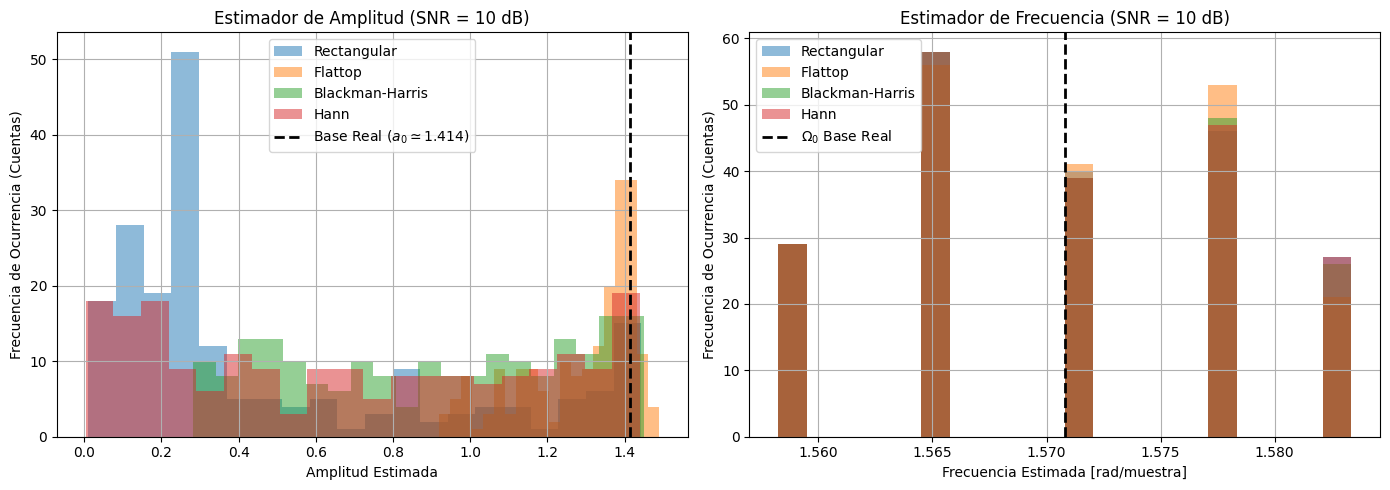

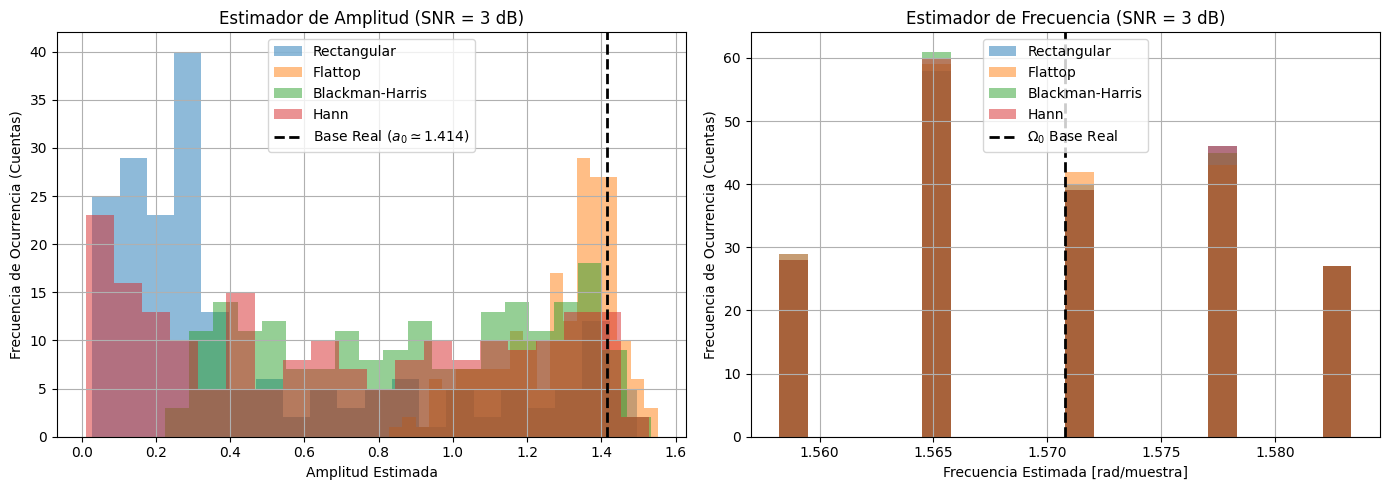

In [16]:
def plotear_histogramas(dict_amp, dict_frec, snr_label):
    fig, (ax_amp, ax_frec) = plt.subplots(1, 2, figsize=(14, 5))
    
    for nombre in dict_ventanas.keys():
        # bins=20 para que se vea bien la campana
        ax_amp.hist(dict_amp[nombre], bins=20, alpha=0.5, label=nombre)
        ax_frec.hist(dict_frec[nombre], bins=20, alpha=0.5, label=nombre)
        
    # --- Formato Gráfico Amplitud ---
    ax_amp.axvline(a0, color='black', linestyle='--', linewidth=2, label=f'Base Real ($a_0 \simeq 1.414$)')
    ax_amp.set_title(f'Estimador de Amplitud (SNR = {snr_label} dB)')
    ax_amp.set_xlabel('Amplitud Estimada')
    ax_amp.set_ylabel('Frecuencia de Ocurrencia (Cuentas)') 
    ax_amp.legend()
    ax_amp.grid(True)
    
    # --- Formato Gráfico Frecuencia ---
    ax_frec.axvline(omega_cero, color='black', linestyle='--', linewidth=2, label='$\Omega_0$ Base Real')
    ax_frec.set_title(f'Estimador de Frecuencia (SNR = {snr_label} dB)')
    ax_frec.set_xlabel('Frecuencia Estimada [rad/muestra]')
    ax_frec.set_ylabel('Frecuencia de Ocurrencia (Cuentas)')
    ax_frec.legend()
    ax_frec.grid(True)
    
    plt.tight_layout()
    plt.show()

plotear_histogramas(amp_10db, frec_10db, "10")
plotear_histogramas(amp_3db, frec_3db, "3")

## 6. Análisis Cuantitativo: Sesgo y Varianza

Para formalizar numéricamente el análisis cualitativo anterior, calculamos dos métricas estadísticas fundamentales para cada ventana temporal y nivel de SNR:

*   **Sesgo ($s$):** Diferencia entre el valor medio esperado del estimador y el valor teórico real. Nos indica si la ventana empleada tiende a sobreestimar o subestimar sistemáticamente la amplitud o la frecuencia (pérdida por *scalloping*).
*   **Varianza ($v$):** Medida de la dispersión de los valores estimados respecto a su propia media. Refleja la sensibilidad y robustez del estimador frente a las fluctuaciones del ruido aditivo.

Los resultados consolidados se presentan a continuación estructurados en tablas de datos.

In [24]:
from IPython.display import display, Markdown

def generar_tablas(dict_amp, dict_frec, snr_label):
    md_text = f"### Tablas de Desempeño: SNR = {snr_label} dB\n\n"
    md_text += "#### Estimación de Amplitud\n\n"
    md_text += "| Ventana | Sesgo ($s_a$) | Varianza ($v_a$) |\n"
    md_text += "|---|---|---|\n"
    
    filas_frec = ""
    
    for nombre in dict_ventanas.keys():
        # Cálculo Estadístico Amplitud (respecto al a0 nominal)
        sesgo_a = np.mean(dict_amp[nombre]) - a0
        var_a = np.var(dict_amp[nombre])
        
        # Cálculo Estadístico Frecuencia (respecto a omega_1 que es la frecuencia real que varió)
        sesgo_w = np.mean(dict_frec[nombre] - omega_1) 
        var_w = np.var(dict_frec[nombre])
        
        md_text += f"| **{nombre}** | {sesgo_a:.3e} | {var_a:.3e} |\n"
        filas_frec += f"| **{nombre}** | {sesgo_w:.3e} | {var_w:.3e} |\n"
        
    md_text += "\n<br>\n\n#### Estimación de Frecuencia\n\n"
    md_text += "| Ventana | Sesgo ($s_\omega$) | Varianza ($v_\omega$) |\n"
    md_text += "|---|---|---|\n"
    md_text += filas_frec
    
    display(Markdown(md_text))

# Imprimimos las tablas
generar_tablas(amp_10db, frec_10db, "10")
generar_tablas(amp_3db, frec_3db, "3")

### Tablas de Desempeño: SNR = 10 dB

#### Estimación de Amplitud

| Ventana | Sesgo ($s_a$) | Varianza ($v_a$) |
|---|---|---|
| **Rectangular** | -9.364e-01 | 1.891e-01 |
| **Flattop** | -1.253e-01 | 2.162e-02 |
| **Blackman-Harris** | -5.109e-01 | 1.315e-01 |
| **Hann** | -7.290e-01 | 2.243e-01 |

<br>

#### Estimación de Frecuencia

| Ventana | Sesgo ($s_\omega$) | Varianza ($v_\omega$) |
|---|---|---|
| **Rectangular** | -1.007e-04 | 6.449e-05 |
| **Flattop** | -1.949e-04 | 6.064e-05 |
| **Blackman-Harris** | -1.007e-04 | 6.410e-05 |
| **Hann** | -6.927e-05 | 6.472e-05 |


### Tablas de Desempeño: SNR = 3 dB

#### Estimación de Amplitud

| Ventana | Sesgo ($s_a$) | Varianza ($v_a$) |
|---|---|---|
| **Rectangular** | -9.351e-01 | 1.872e-01 |
| **Flattop** | -1.327e-01 | 2.486e-02 |
| **Blackman-Harris** | -5.152e-01 | 1.340e-01 |
| **Hann** | -7.296e-01 | 2.235e-01 |

<br>

#### Estimación de Frecuencia

| Ventana | Sesgo ($s_\omega$) | Varianza ($v_\omega$) |
|---|---|---|
| **Rectangular** | -1.007e-04 | 6.449e-05 |
| **Flattop** | -2.264e-04 | 6.396e-05 |
| **Blackman-Harris** | -1.635e-04 | 6.403e-05 |
| **Hann** | -1.007e-04 | 6.410e-05 |


## 7. Conclusiones

A partir de los histogramas y las tablas de desempeño para 10 dB y 3 dB, podemos extraer las siguientes conclusiones fundamentales sobre el comportamiento de los estimadores:

*   **Estimación de Amplitud (El triunfo de Flattop):** 
    *   La ventana **Flattop** demuestra ser abrumadoramente superior para estimar la amplitud real de la señal. 
    *   A 10 dB, presenta el sesgo más pequeño (-0.125) y la varianza más baja (0.022) de todo el grupo. 
    *   Esta robustez se mantiene a 3 dB.
    *   Esto ocurre porque la ventana Flattop tiene un lóbulo principal ancho y plano, diseñado específicamente para minimizar el error de *scalloping loss* (festoneo) cuando la frecuencia real cae entre dos *bins* de la FFT.
    *   Por el contrario, la ventana **Rectangular** es la peor opción para medir amplitud.
    *   Presenta un sesgo negativo severo (aprox. -0.93) subestimando gravemente el valor real debido a la alta fuga espectral (*spectral leakage*) cuando la señal no es periódica en la ventana.

*   **Estimación de Frecuencia (Resolución discreta):** 
    *   A diferencia de la amplitud, todas las ventanas presentan un desempeño casi idéntico al estimar la frecuencia. 
    *   Los sesgos rondan el orden de $10^{-4}$ y las varianzas el orden de $10^{-5}$ para todas las ventanas en ambos escenarios de ruido.
    *   Al observar los histogramas de frecuencia, vemos barras discretas fuertemente marcadas. 
    *   Esto indica que el error dominante aquí no es el ruido ni la ventana elegida, sino la **resolución frecuencial de la FFT** (el ancho del *bin*, $\Delta f = \frac{f_s}{N}$). El estimador `argmax` simplemente queda "atrapado" en el *bin* más cercano a la frecuencia real.

*   **Efecto de la Relación Señal a Ruido (SNR):** 
    *   Al degradar el canal de 10 dB a 3 dB, los estimadores no colapsan, manteniendo una estructura similar.
    *   El sesgo se mantiene prácticamente idéntico entre ambos escenarios (ej. el sesgo de amplitud de Blackman-Harris pasa de -0.510 a -0.515).
    *   La varianza sufre un incremento marginal debido a la mayor dispersión generada por el piso de ruido más alto.

## Bonus 💎: Efecto del Zero-Padding en el estimador $\hat{\Omega}_1$


Para comprobar cómo el relleno con ceros mejora la estimación de frecuencia, vamos a generar una señal senoidal pura cuya frecuencia real **no coincida** con ningún canal exacto (*bin*) de la FFT estándar. 

Calcularemos el estimador de frecuencia de dos maneras:
1. Usando la **FFT normal** de $N$ puntos.
2. Usando una **FFT con Zero-Padding** de $10 \times N$ puntos.

Luego, compararemos el error absoluto de ambas estimaciones y lo graficaremos.

Frecuencia Real de la señal: 154.3 Hz
► SIN Zero-Padding (N = 100)
  Estimación: 150.00 Hz  |  Error: 4.30 Hz

► CON Zero-Padding (N = 1000)
  Estimación: 154.00 Hz  |  Error: 0.30 Hz


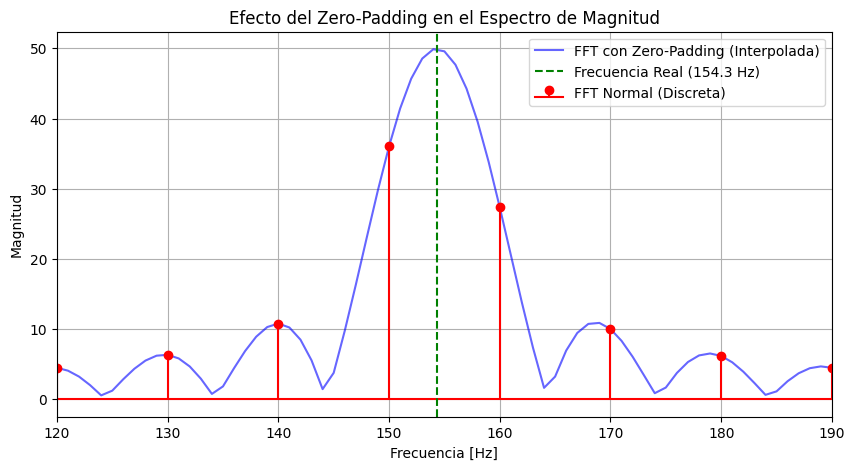

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros de la simulación
N = 100            # Cantidad de muestras originales
fs = 1000          # Frecuencia de muestreo (Hz)
t = np.arange(N) / fs

# Elegimos una frecuencia "incómoda" que caiga entre dos bins de la FFT normal
# La resolución normal es fs/N = 1000/100 = 10 Hz por bin. 
# 154.3 Hz caerá a la mitad, forzando un error en el estimador estándar.
f_real = 154.3     
x = np.cos(2 * np.pi * f_real * t)

# 2. FFT Normal (Sin Zero-Padding)
X_normal = np.fft.fft(x)
freqs_normal = np.fft.fftfreq(N, 1/fs)

# Buscamos el pico en la primera mitad del espectro
k_max_normal = np.argmax(np.abs(X_normal[:N//2]))
f_est_normal = freqs_normal[k_max_normal]
error_normal = np.abs(f_real - f_est_normal)

# 3. FFT con Zero-Padding
N_pad = N * 10  # Multiplicamos el tamaño por 10 (agregamos 900 ceros)
# Le pasamos el parámetro 'n' a np.fft.fft. Automáticamente rellena con ceros hasta N_pad
X_pad = np.fft.fft(x, n=N_pad) 
freqs_pad = np.fft.fftfreq(N_pad, 1/fs)

k_max_pad = np.argmax(np.abs(X_pad[:N_pad//2]))
f_est_pad = freqs_pad[k_max_pad]
error_pad = np.abs(f_real - f_est_pad)

# 4. Resultados en texto
print("==================================================")
print(f"Frecuencia Real de la señal: {f_real} Hz")
print("==================================================")
print(f"► SIN Zero-Padding (N = {N})")
print(f"  Estimación: {f_est_normal:.2f} Hz  |  Error: {error_normal:.2f} Hz")
print(f"\n► CON Zero-Padding (N = {N_pad})")
print(f"  Estimación: {f_est_pad:.2f} Hz  |  Error: {error_pad:.2f} Hz")
print("==================================================")

# 5. Gráfico comparativo
plt.figure(figsize=(10, 5))

# Graficamos el espectro interpolado (con zero-padding) en línea continua
plt.plot(freqs_pad[:N_pad//2], np.abs(X_pad[:N_pad//2]), 
         label='FFT con Zero-Padding (Interpolada)', color='blue', alpha=0.6)

# Graficamos los puntos discretos de la FFT original
plt.stem(freqs_normal[:N//2], np.abs(X_normal[:N//2]), 
         linefmt='r-', markerfmt='ro', basefmt='r-', 
         label='FFT Normal (Discreta)')

# Marcamos la frecuencia real
plt.axvline(f_real, color='green', linestyle='--', label=f'Frecuencia Real ({f_real} Hz)')

plt.xlim(120, 190)
plt.title('Efecto del Zero-Padding en el Espectro de Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la Simulación

Los resultados obtenidos en la consola y el gráfico confirman empíricamente el beneficio teórico del zero-padding:

* **Limitación de la FFT discreta:** Al calcular la FFT original con $N=100$, la grilla frecuencial queda limitada. El algoritmo seleccionó el *bin* discreto más cercano en 150.00 Hz, lo que produjo un error de estimación de 4.30 Hz respecto a la frecuencia real de 154.3 Hz. En el gráfico, esto se evidencia en el tallo rojo central, cuyo valor máximo no coincide con la ubicación de la línea punteada verde.
* **Mejora en la estimación:** Al aplicar zero-padding ($N=1000$), densificamos la grilla espectral. Esto permitió que el estimador ubicara el nuevo pico en 154.00 Hz, reduciendo el error drásticamente a tan solo 0.30 Hz.
* **Interpolación visual:** La curva violeta demuestra cómo el relleno con ceros interpola la Transformada de Fourier, revelando la verdadera forma del lóbulo principal y permitiendo que la estimación se acerque con gran precisión a la frecuencia real de la señal.